### AARRR 지표정의

Activation | 첫 거래 후 30일 이내 2번째 거래 발생 | 첫 거래 후 재거래 여부

Retention | 첫 거래 연도 다음 연도에도 거래 발생 | 연도 기준 재방문

Revenue | 유저별 평균 거래금액 및 총 거래금액 | ltv_transactions 기준

Referral | 이 데이터엔 없음 → 스킵 | -

In [1]:
# Cell 1 - 라이브러리 및 DB 연결

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = r'..\data\db\fintech.db'
conn = sqlite3.connect(DB_PATH)
print("DB 연결 완료")

DB 연결 완료


In [2]:
# Cell 2 - Acquisition: 연도별 신규 유저 수

acquisition_query = """
SELECT
    first_year,
    COUNT(DISTINCT User) AS new_users
FROM (
    SELECT
        User,
        MIN(Year) AS first_year
    FROM clean_transactions
    GROUP BY User
) first_tx
GROUP BY first_year
ORDER BY first_year
"""

acquisition = pd.read_sql(acquisition_query, conn)
print("=== Acquisition: 연도별 신규 유저 ===")
print(acquisition)

=== Acquisition: 연도별 신규 유저 ===
    first_year  new_users
0         1991          3
1         1992          2
2         1993          5
3         1994          8
4         1995          7
5         1996         17
6         1997         27
7         1998         38
8         1999         55
9         2000         61
10        2001         97
11        2002        112
12        2003        118
13        2004        138
14        2005        139
15        2006        140
16        2007        139
17        2008        131
18        2009         97
19        2010         89
20        2011         48
21        2012         26
22        2013         22
23        2014         19
24        2015         23
25        2016         15
26        2017         14
27        2018         16
28        2019         51


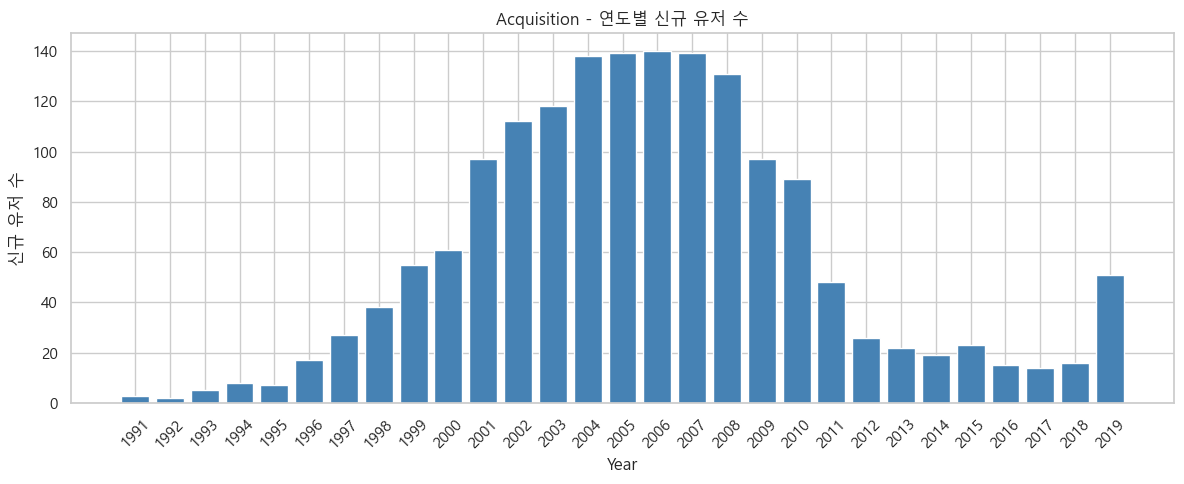


전체 유저 수: 1,657명
평균 연간 신규 유저: 57명


In [3]:
# Cell 3 - Acquisition 시각화

###################################################################
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
###################################################################

plt.figure(figsize=(12, 5))
plt.bar(acquisition['first_year'], acquisition['new_users'], color='steelblue')
plt.title('Acquisition - 연도별 신규 유저 수')
plt.xlabel('Year')
plt.ylabel('신규 유저 수')
plt.xticks(acquisition['first_year'], rotation=45) # x축 레이블 회전
plt.tight_layout() # 그래프 요소 간격 조정
plt.savefig(r'..\outputs\aarrr_acquisition.png', dpi=150)
plt.show()

total_users = acquisition['new_users'].sum()
print(f"\n전체 유저 수: {total_users:,}명")
print(f"평균 연간 신규 유저: {total_users/len(acquisition):.0f}명")
# 연도별 신규 유저 수의 평균 계산 및 소수점 제거하여 출력

*인사이트*

- 2004~2007년이 신규 유저 획득 피크 (연간 138~140명). 
- 2008년 이후 급격히 감소하는데 2008년 금융위기 영향으로 보임. 합성 데이터지만 실제 경제 패턴을 반영해서 만들어져서 그런듯.
- 2019년에 51명으로 소폭 반등함.
+ 전체 유저가 2,000명인데 1,657명라고 나온 이유는 ? 

In [4]:
# 유저 수 확인 쿼리

# 1. 전체 transactions에서 유저 수
q1 = pd.read_sql("SELECT COUNT(DISTINCT User) as cnt FROM transactions", conn)
print(f"전체 transactions 유저 수: {q1['cnt'].values[0]}")

# 2. 사기 제외 후
q2 = pd.read_sql("SELECT COUNT(DISTINCT User) as cnt FROM transactions WHERE \"Is Fraud?\" = 'No'", conn)
print(f"사기 제외 후 유저 수: {q2['cnt'].values[0]}")

# 3. 2020년 제외 후
q3 = pd.read_sql("SELECT COUNT(DISTINCT User) as cnt FROM clean_transactions", conn)
print(f"2020년 제외 후 유저 수: {q3['cnt'].values[0]}")

# 4. users 테이블
q4 = pd.read_sql("SELECT COUNT(DISTINCT person) as cnt FROM users", conn)
print(f"users 테이블 유저 수: {q4['cnt'].values[0]}")

전체 transactions 유저 수: 2000
사기 제외 후 유저 수: 2000
2020년 제외 후 유저 수: 1657
users 테이블 유저 수: 1993


- 343명의 유저가 2020년에 카드를 처음 쓰기 시작했는데 2020년을 제외해서 전체 유저수가 1657명이 됨
- user테이블이 2000명이 아닌 1993명임 -> 7명은 user테이블에 없는 유저. 데이터 생성 과정의 미세한 오류인듯.

=> 2019년까지 거래이력이 있는 1657명 유저 기준으로 분석 진행

---

In [5]:
# Cell 4 - Activation: 첫 거래 후 30일 이내 재거래 비율

activation_query = """
WITH first_tx AS (
    SELECT
        User,
        MIN(date_int) AS first_date,
        MIN(Year) AS first_year
    FROM clean_transactions
    GROUP BY User
),
second_tx AS (
    SELECT
        c.User,
        MIN(c.date_int) AS second_date
    FROM clean_transactions c
    JOIN first_tx f ON c.User = f.User
    WHERE c.date_int > f.first_date
    GROUP BY c.User
)
SELECT
    COUNT(DISTINCT f.User) AS acquired_users,
    COUNT(DISTINCT s.User) AS had_second_tx,
    COUNT(DISTINCT CASE
        WHEN (s.second_date - f.first_date) <= 30
        THEN f.User
    END) AS activated_users,
    ROUND(
        COUNT(DISTINCT CASE
            WHEN (s.second_date - f.first_date) <= 30
            THEN f.User
        END) * 100.0 / COUNT(DISTINCT f.User), 2
    ) AS activation_rate
FROM first_tx f
LEFT JOIN second_tx s ON f.User = s.User
"""

activation = pd.read_sql(activation_query, conn)
print("=== Activation ===")
print(activation)

=== Activation ===
   acquired_users  had_second_tx  activated_users  activation_rate
0            1657           1618             1093            65.96


*Activation 65.96%*— 첫 거래 후 30일 내 재거래한 유저 비율. 

이 데이터는 30년 거래 데이터라 30일 내 재거래 안 한 유저가 거의 없을 것 같은데 34%가 안 했다는 게 의외임. 개선포인트.


In [6]:
# Cell 5 - Retention: 첫 거래 다음 연도에도 거래한 유저 비율

retention_query = """
WITH first_year AS (
    SELECT
        User,
        MIN(Year) AS first_year
    FROM clean_transactions
    GROUP BY User
),
next_year_tx AS (
    SELECT DISTINCT
        c.User
    FROM clean_transactions c
    JOIN first_year f ON c.User = f.User
    WHERE c.Year = f.first_year + 1
)
SELECT
    COUNT(DISTINCT f.User) AS acquired_users,
    COUNT(DISTINCT n.User) AS retained_users,
    ROUND(
        COUNT(DISTINCT n.User) * 100.0 / COUNT(DISTINCT f.User), 2
    ) AS retention_rate
FROM first_year f
LEFT JOIN next_year_tx n ON f.User = n.User
"""

retention = pd.read_sql(retention_query, conn)
print("=== Retention (1년 후) ===")
print(retention)

=== Retention (1년 후) ===
   acquired_users  retained_users  retention_rate
0            1657            1584           95.59


*Retention 95.59%* — 첫 거래 다음 연도에도 거래한 유저 비율.

이건 너무 높음. 30년치 데이터라 대부분 유저가 카드 특성상 한번 쓰기 시작해서 다음 해에도 당연히 거래했을 것으로 보임. 
이 지표는 큰 의미가 없다. Cohort에서 "몇 년 후까지 유지되는지"를 보는 게 더 의미있을 것으로 보임

In [7]:
# Cell 6 - Revenue: 유저별 총 거래금액

revenue_query = """
SELECT
    COUNT(DISTINCT User) AS total_users,
    ROUND(AVG(total_amount), 2) AS avg_ltv,
    ROUND(MIN(total_amount), 2) AS min_ltv,
    ROUND(MAX(total_amount), 2) AS max_ltv,
    -- 중앙값 대신 사분위수
    COUNT(CASE WHEN total_amount > 10000 THEN 1 END) AS high_value_users
FROM (
    SELECT
        User,
        SUM(Amount) AS total_amount
    FROM ltv_transactions
    GROUP BY User
)
"""

revenue = pd.read_sql(revenue_query, conn)
print("=== Revenue ===")
print(revenue)

=== Revenue ===
   total_users   avg_ltv  min_ltv     max_ltv  high_value_users
0         1657  692326.3    36.59  4868629.35              1604


*Revenue* — avg_ltv가 $692,326. 

- 30년치 누적 합산이라 높게 나옴. 연간 평균으로 나눠야 의미있음. 
연간으로 나누면 약 $23,000 수준
-  high_value_users는 10000달러를 기준으로함, 유저마다 관찰기간이 다르기 때문에 단순누적금액으로 high value 유저를 구분하는 건 문제가 있음

- revenue단계는 얼마나 많은 유저가 실제로 돈을 썼는가 이지만 우리 데이터는 카드 거래 데이터라서  거래 자체가 revenue임. 별도의 유료전환이 없음.
- 데이터 특성상 Acquisition와 동일함
- 이 데이터셋은 Revenue 단계를 직접 측정하기 어려운 구조라 연간 LTV로 대체해야할듯

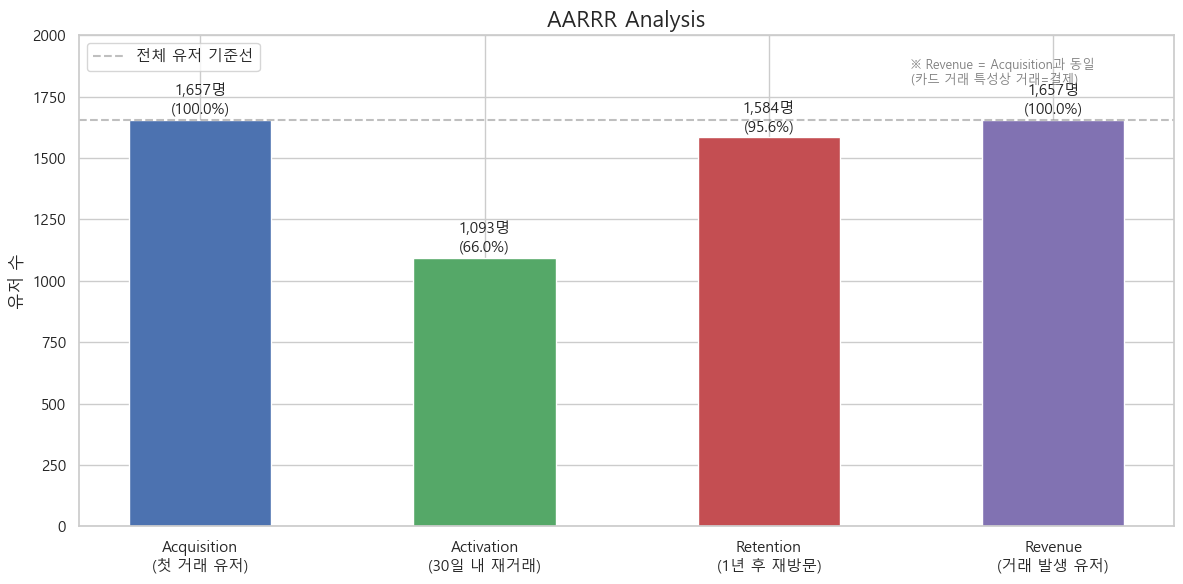

In [11]:
# Cell 7  - AARRR 최종 시각화

funnel_data = {
    'Acquisition\n(첫 거래 유저)': 1657,
    'Activation\n(30일 내 재거래)': 1093,
    'Retention\n(1년 후 재방문)': 1584,
    'Revenue\n(거래 발생 유저)': 1657  # Acquisition과 동일
}

fig, ax = plt.subplots(figsize=(12, 6))
stages = list(funnel_data.keys())
values = list(funnel_data.values())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = ax.bar(stages, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    pct = val / 1657 * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}명\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('AARRR Analysis', fontsize=16)
ax.set_ylabel('유저 수')
ax.set_ylim(0, 2000)
ax.axhline(y=1657, color='gray', linestyle='--', alpha=0.5, label='전체 유저 기준선')

# Revenue 데이터 특성 주석 추가
ax.annotate('※ Revenue = Acquisition과 동일\n(카드 거래 특성상 거래=결제)',
            xy=(3, 1657), xytext=(2.5, 1800),
            fontsize=9, color='gray')

ax.legend()
plt.tight_layout()
plt.savefig(r'..\outputs\aarrr_final.png', dpi=150)
plt.show()

Acquisition (1,657명)

Activation  (1,657명 중 30일 내 재거래) ← 독립 계산

Retention   (1,657명 중 1년 후 재거래)  ← 독립 계산 (Activation 여부 무관)

In [12]:
# Cell 8 - Activation × Retention 교차 분석

cross_query = """
WITH first_tx AS (
    SELECT
        User,
        MIN(date_int) AS first_date,
        MIN(Year) AS first_year
    FROM clean_transactions
    GROUP BY User
),
second_tx AS (
    SELECT
        c.User,
        MIN(c.date_int) AS second_date
    FROM clean_transactions c
    JOIN first_tx f ON c.User = f.User
    WHERE c.date_int > f.first_date
    GROUP BY c.User
),
next_year AS (
    SELECT DISTINCT
        c.User
    FROM clean_transactions c
    JOIN first_tx f ON c.User = f.User
    WHERE c.Year = f.first_year + 1
),
user_flags AS (
    SELECT
        f.User,
        CASE WHEN (s.second_date - f.first_date) <= 30
            THEN 1 ELSE 0 END AS is_activated,
        CASE WHEN n.User IS NOT NULL
            THEN 1 ELSE 0 END AS is_retained
    FROM first_tx f
    LEFT JOIN second_tx s ON f.User = s.User
    LEFT JOIN next_year n ON f.User = n.User
)
SELECT
    CASE
        WHEN is_activated = 1 AND is_retained = 1 THEN '진성 유저'
        WHEN is_activated = 1 AND is_retained = 0 THEN '초반 반짝 유저'
        WHEN is_activated = 0 AND is_retained = 1 THEN '느린 정착형 유저'
        ELSE '이탈 유저'
    END AS user_type,
    COUNT(*) AS user_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM first_tx), 2) AS ratio
FROM user_flags
GROUP BY user_type
ORDER BY user_count DESC
"""

cross = pd.read_sql(cross_query, conn)
print("=== Activation × Retention 유저 세그멘테이션 ===")
print(cross)

=== Activation × Retention 유저 세그멘테이션 ===
   user_type  user_count  ratio
0      진성 유저        1066  64.33
1  느린 정착형 유저         518  31.26
2      이탈 유저          46   2.78
3   초반 반짝 유저          27   1.63


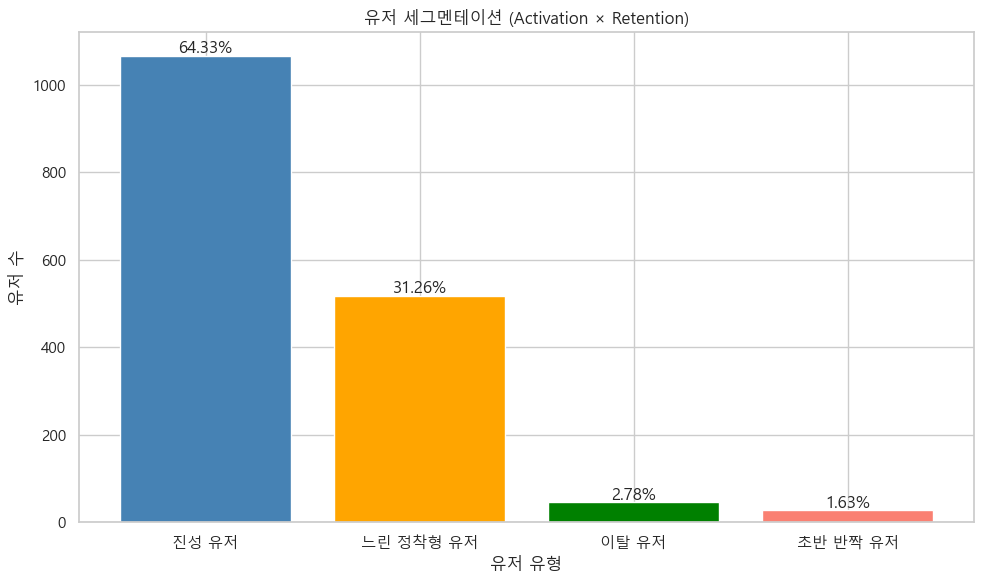

In [ ]:
# Cell 9 - 시각화

plt.figure(figsize=(10, 6))
colors = ['steelblue', 'orange', 'green', 'salmon']
bars = plt.bar(cross['user_type'], cross['user_count'], color=colors)

for bar, ratio in zip(bars, cross['ratio']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{ratio}%',
             ha='center', fontsize=12)

plt.title('유저 세그멘테이션 (Activation × Retention)')
plt.xlabel('유저 유형')
plt.ylabel('유저 수')
plt.tight_layout()
plt.savefig(r'..\outputs\aarrr_user_segments.png', dpi=150)
plt.show()

30일 내 재거래 O + 1년 후 유지 O → 진성 유저 (핵심 타겟)

30일 내 재거래 O + 1년 후 유지 X → 초반 반짝 유저

30일 내 재거래 X + 1년 후 유지 O → 느린 정착형 유저

30일 내 재거래 X + 1년 후 유지 X → 이탈 유저

- 진성 유저 64.33% — Activation도 빠르고 Retention도 됨
- 느린 정착형 31.26% — 30일 내 재거래는 못했지만 결국 정착함
- 이탈 유저 2.78% — Activation도 안 되고 Retention도 안 됨
- 초반 반짝 유저 1.63% — 처음엔 빠르게 썼지만 이탈

=> A/B테스트 가설
- 우리 서비스가 초기에 36%의 유저를 충분히 engage 시키지 못하고 있다
- 느린 정착형 유저(31%)를 진성 유저로 전환할 수 있다면?
- 이 유저들은 결국 정착은 했는데 초기 Activation이 느렸음. 초기 넛지(리마인드 알림 등)가 있었다면 더 빨리 활성화됐을 수 있음
- 첫 거래 후 7일, 14일, 30일 시점에 맞춤 알림을 보내면 느린 정착형 유저의 Activation을 앞당길 수 있다 >> 라는 가설을 세울 수 있음

In [ ]:
# Cell 10 - AARRR 순차 FUNNEL

funnel_query = """
WITH 
-- Step 1: Acquisition (첫 거래 유저)
acquisition AS (
    SELECT
        User,
        MIN(date_int) AS first_date,
        MIN(Year) AS first_year
    FROM clean_transactions
    GROUP BY User
),
-- Step 2: Activation (Acquisition 유저 중 30일 내 재거래)
activation AS (
    SELECT DISTINCT c.User
    FROM clean_transactions c
    JOIN acquisition a ON c.User = a.User
    WHERE c.date_int > a.first_date
    AND (c.date_int - a.first_date) <= 30
),
-- Step 3: Retention (Activation 유저 중 다음 연도에도 거래)
retention AS (
    SELECT DISTINCT c.User
    FROM clean_transactions c
    JOIN acquisition a ON c.User = a.User
    JOIN activation act ON c.User = act.User
    WHERE c.Year = a.first_year + 1
)
SELECT
    COUNT(DISTINCT a.User)   AS acquisition,
    COUNT(DISTINCT act.User) AS activation,
    COUNT(DISTINCT r.User)   AS retention
FROM acquisition a
LEFT JOIN activation act ON a.User = act.User
LEFT JOIN retention r ON a.User = r.User
"""

funnel = pd.read_sql(funnel_query, conn)
print("=== 순차 퍼널 ===")
print(funnel)
print(f"\nAcquisition → Activation : {funnel['activation'].values[0]/funnel['acquisition'].values[0]*100:.1f}%")
print(f"Activation  → Retention  : {funnel['retention'].values[0]/funnel['activation'].values[0]*100:.1f}%")

=== 순차 퍼널 ===
   acquisition  activation  retention
0         1657        1093       1066

Acquisition → Activation : 66.0%
Activation  → Retention  : 97.5%


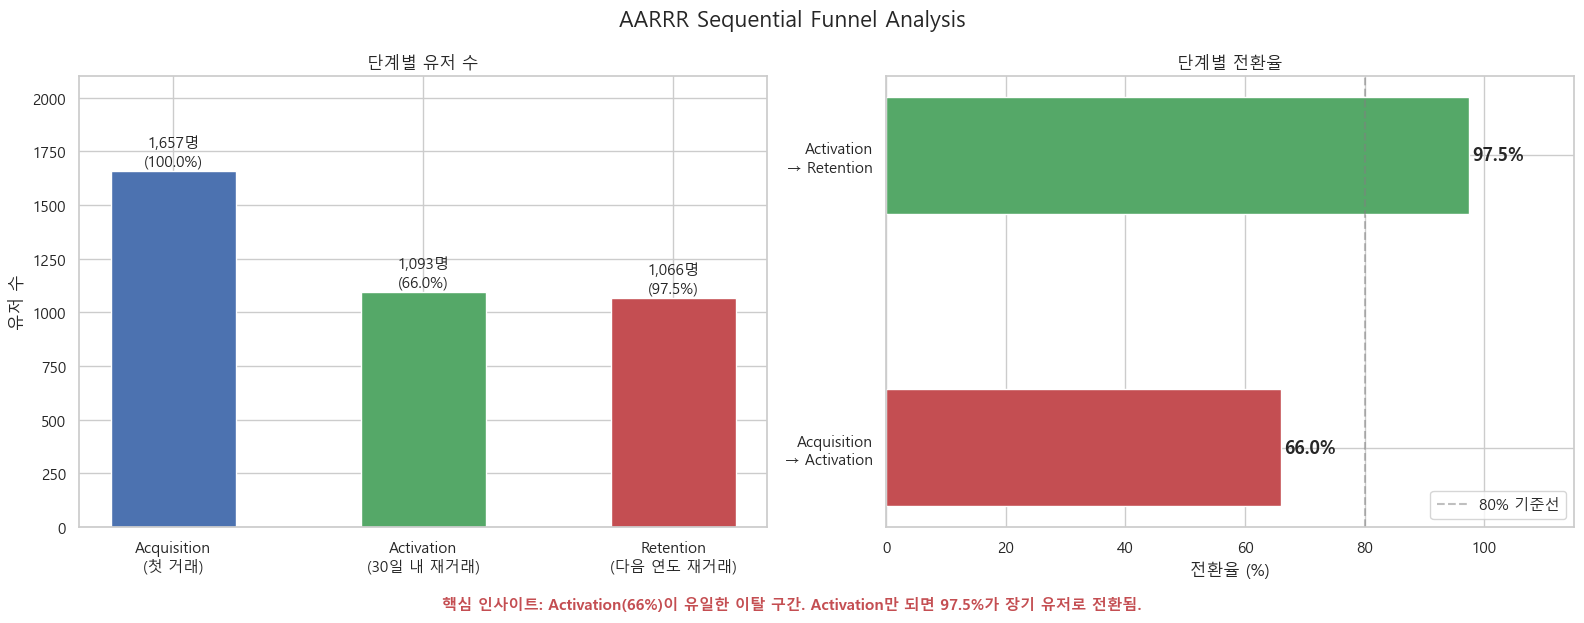

In [13]:
# Cell 11 - AARRR 순차 FUNNEL 시각화

import matplotlib.patches as mpatches

funnel_stages = ['Acquisition\n(첫 거래)', 'Activation\n(30일 내 재거래)', 'Retention\n(다음 연도 재거래)']
funnel_values = [1657, 1093, 1066]
funnel_colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AARRR Sequential Funnel Analysis', fontsize=16)

# 왼쪽: 바 차트
bars = axes[0].bar(funnel_stages, funnel_values, color=funnel_colors, width=0.5)
for bar, val, total in zip(bars, funnel_values, [1657, 1657, 1093]):
    pct = val / total * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}명\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_ylabel('유저 수')
axes[0].set_ylim(0, 2100)
axes[0].set_title('단계별 유저 수')

# 오른쪽: 전환율 강조
conversion_labels = ['Acquisition\n→ Activation', 'Activation\n→ Retention']
conversion_values = [66.0, 97.5]
conversion_colors = ['#C44E52', '#55A868']

bars2 = axes[1].barh(conversion_labels, conversion_values, color=conversion_colors, height=0.4)
for bar, val in zip(bars2, conversion_values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 115)
axes[1].set_xlabel('전환율 (%)')
axes[1].set_title('단계별 전환율')
axes[1].axvline(x=80, color='gray', linestyle='--', alpha=0.5, label='80% 기준선')
axes[1].legend()

# 핵심 인사이트 텍스트
fig.text(0.5, -0.02,
         '핵심 인사이트: Activation(66%)이 유일한 이탈 구간. Activation만 되면 97.5%가 장기 유저로 전환됨.',
         ha='center', fontsize=11, color='#C44E52', fontweight='bold')

plt.tight_layout()
plt.savefig(r'..\outputs\aarrr_funnel_sequential.png', dpi=150, bbox_inches='tight')
plt.show()

핵심 인사이트

Activation한 유저 중 97.5%가 Retention 됨 ->  즉 "30일 내 재거래만 일어나면 거의 모든 유저가 장기 유저가 된다" 는 게 데이터로 증명됐음. A/B 테스트 가설이 더 강해짐 !!